# Evaluating health hazards in relation to 911 EMS calls

General pollution and overall impact on health. In combination with additional environmental and systemic factors like education, linguistic isolation, poverty. 
Could evaluate how that impacts demographics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import geopandas as gpd
import numpy as np
import requests


In [2]:
emergency = pd.read_csv("Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service_20260315.csv")

In [13]:
emergency.columns

Index(['Call Number', 'Unit ID', 'Incident Number', 'Call Type', 'Call Date',
       'Received DtTm', 'Entry DtTm', 'Dispatch DtTm', 'Response DtTm',
       'On Scene DtTm', 'Transport DtTm', 'Hospital DtTm',
       'Call Final Disposition', 'Available DtTm', 'Address', 'City',
       'Zipcode of Incident', 'Battalion', 'Station Area', 'Original Priority',
       'Priority', 'Final Priority', 'ALS Unit', 'Call Type Group',
       'Number of Alarms', 'Unit Type', 'Unit sequence in call dispatch',
       'Fire Prevention District', 'Supervisor District',
       'Neighborhooods - Analysis Boundaries', 'RowID', 'case_location'],
      dtype='object')

In [33]:
emergency['Call Date']

0         12/31/2024
1         12/31/2024
2         12/31/2024
3         12/31/2024
4         12/31/2024
             ...    
368895    12/30/2025
368896    12/30/2025
368897    12/30/2025
368898    12/30/2025
368899    12/30/2025
Name: Call Date, Length: 368886, dtype: object

In [103]:
emergency.head()

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,Call Type Group,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location,geometry
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,Non Life-threatening,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755),POINT (-122.411015164 37.78418755)
1,243660122,E36,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:59 AM,2024 Dec 31 01:40:54 AM,...,Alarm,1,ENGINE,1.0,2.0,5.0,Hayes Valley,243660122-E36,POINT (-122.42105326 37.775695233),POINT (-122.42105326 37.775695233)
2,243660122,B02,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:02 AM,2024 Dec 31 01:41:31 AM,...,Alarm,1,CHIEF,2.0,2.0,5.0,Hayes Valley,243660122-B02,POINT (-122.42105326 37.775695233),POINT (-122.42105326 37.775695233)
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,Potentially Life-Threatening,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006),POINT (-122.434729992 37.784944006)
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351),POINT (-122.367922359 37.727398351)


In [40]:
med_inc = emergency[emergency['Call Type']=='Medical Incident']
len(med_inc)

241314

In [61]:
med_inc_day = med_inc[med_inc['Call Date']=='01/05/2025']

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_44074/1224533333.py:12: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood') #cmap='tab20')


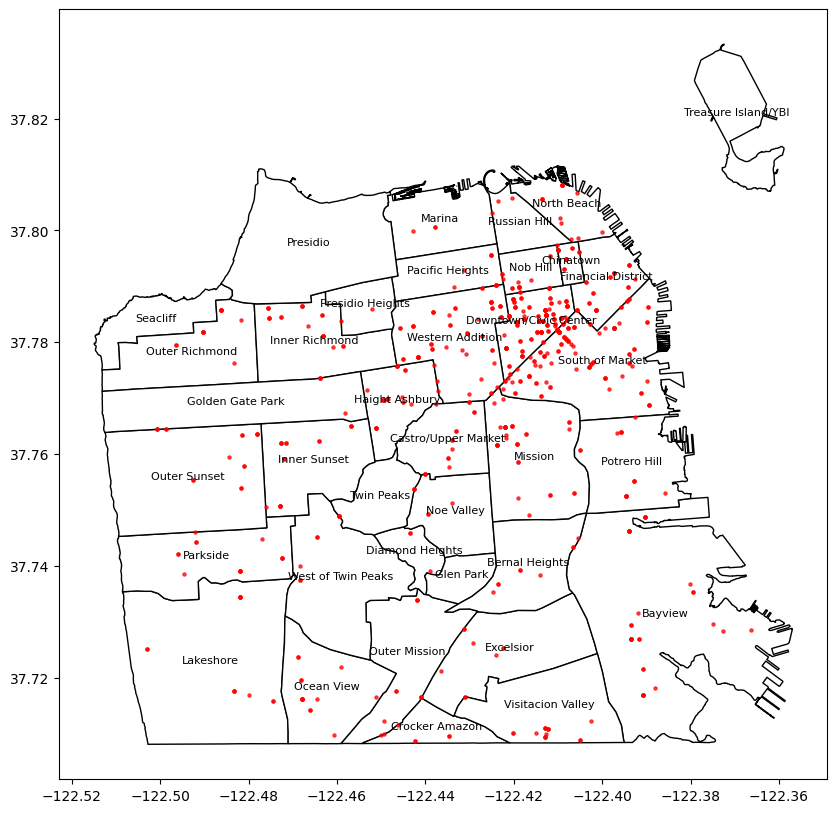

In [63]:
from shapely import wkt

# 1. Load SF Neighborhood Boundaries
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')

sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")


fig, ax = plt.subplots(figsize=(10, 10))

sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood') #cmap='tab20')
# Project for accurate centroids
sf_map_proj = sf_map.to_crs(epsg=3857)
centroids = sf_map_proj.geometry.centroid.to_crs(sf_map.crs)
# Add labels
for x, y, label in zip(centroids.x, centroids.y, sf_map['neighborho']):
    ax.text(x, y, label, fontsize=8, ha='center')



med_inc_day = med_inc_day.dropna(subset=['case_location'])
# Plot emergency data
# 1. Convert the 'case_location' strings to actual geometry objects
med_inc_day['geometry'] = med_inc_day['case_location'].apply(wkt.loads)

# 2. Convert the pandas DataFrame to a GeoDataFrame
# We use EPSG:4326 because that's the standard for Lat/Long coordinates
med_inc_gdf = gpd.GeoDataFrame(med_inc_day, geometry='geometry', crs="EPSG:4326")


# Plot the emergency points on top
# 'markersize' controls the dot size; 'alpha' helps with overlapping points
med_inc_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.7, label='Emergency Calls')

plt.show()

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_44074/2758578782.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zip_centroids = med_inc_gdf.dissolve(by='Zipcode of Incident').centroid


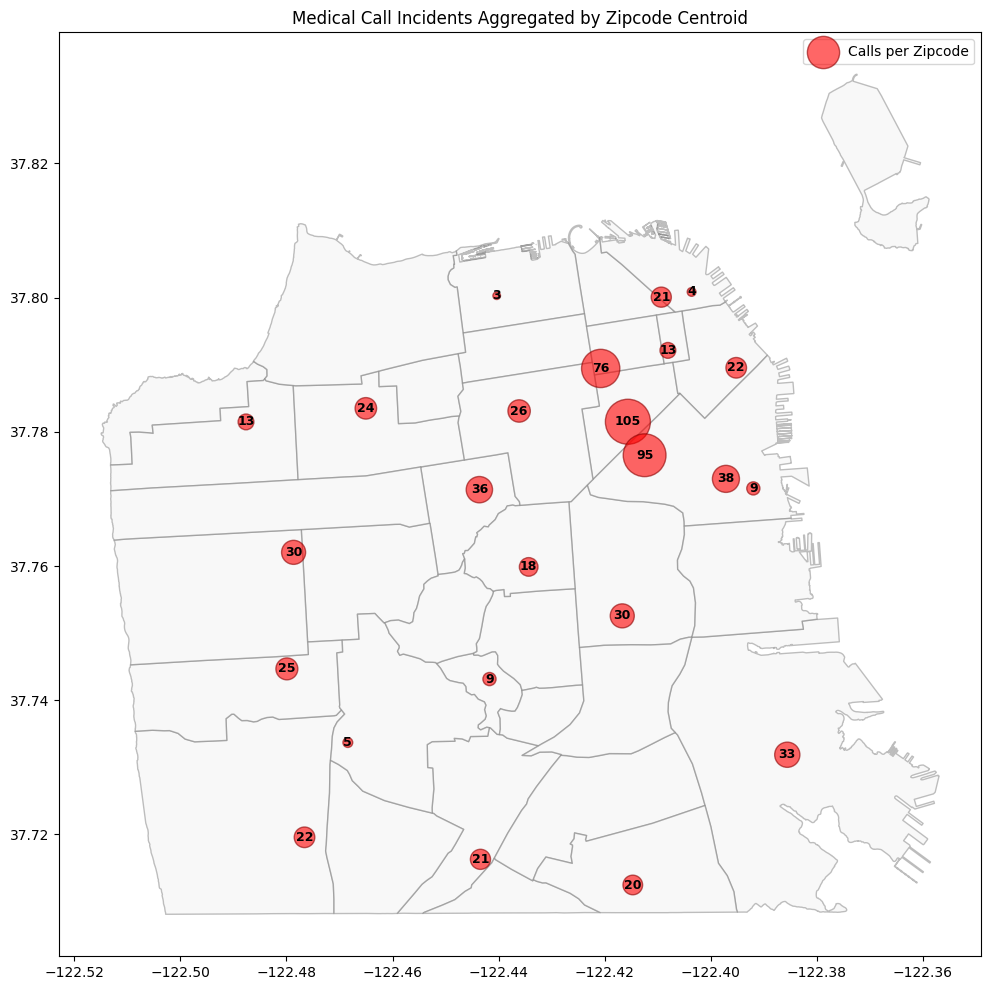

In [67]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

# 1. Load and Prepare SF Map (assuming this file contains geometry)
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')
sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")

# 2. Prepare Medical Incidents
med_inc_day = med_inc_day.dropna(subset=['case_location'])
med_inc_day['geometry'] = med_inc_day['case_location'].apply(wkt.loads)
med_inc_gdf = gpd.GeoDataFrame(med_inc_day, geometry='geometry', crs="EPSG:4326")

# 3. Aggregate by Zipcode
# Note: Ensure med_inc_gdf has a 'zipcode' column. 
# If it doesn't, you'd need a spatial join with a zipcode shapefile first.
zip_counts = med_inc_gdf.groupby('Zipcode of Incident').size().reset_index(name='call_count')

# 4. Get Centroids for Zipcodes
# For this to work, you need a GeoDataFrame of Zipcode boundaries
# If you only have point data, we can approximate the centroid of the points per zip
zip_centroids = med_inc_gdf.dissolve(by='Zipcode of Incident').centroid
zip_summary = gpd.GeoDataFrame(zip_counts, geometry=zip_centroids[zip_counts['Zipcode of Incident']].values, crs="EPSG:4326")

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the base map
sf_map.plot(ax=ax, color='#f2f2f2', edgecolor='grey', alpha=0.5)

# Plot scaled dots
# We use 'markersize' proportional to 'call_count'
# You might need to multiply call_count by a factor (e.g., * 5) for visibility
zip_summary.plot(
    ax=ax, 
    color='red', 
    markersize=zip_summary['call_count'] * 10, 
    alpha=0.6, 
    edgecolor='darkred',
    label='Calls per Zipcode'
)

# Optional: Add Labels for call counts
for x, y, label in zip(zip_summary.geometry.x, zip_summary.geometry.y, zip_summary['call_count']):
    ax.text(x, y, str(label), fontsize=9, fontweight='bold', ha='center', va='center')

plt.title('Medical Call Incidents Aggregated by Zipcode Centroid')
plt.legend()
plt.show()

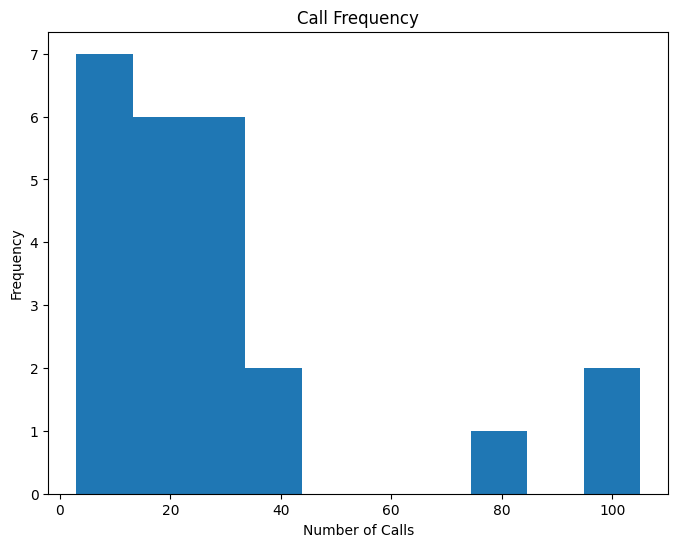

In [83]:
zip_counts
zip_counts['call_count'].hist(bins=10, grid=False, figsize=(8,6))
plt.title('Call Frequency')
plt.ylabel('Frequency')
plt.xlabel('Number of Calls')
plt.show()

In [85]:
print(f"mean: {zip_counts['call_count'].mean()}", 
        f"variance: {zip_counts['call_count'].var()}")

mean: 29.083333333333332 variance: 702.427536231884


In [73]:
hazards_all = pd.read_excel("calenviroscreen40resultsdatadictionary_F_2021.xlsx", sheet_name=None)
hazards = hazards_all['CES4.0FINAL_results']
demographics = hazards_all['Demographic Profile']
dictionary = hazards_all['Data Dictionary']

In [74]:
hazards.head()

,Census Tract,Total Population,California County,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,6019001100,2780,Fresno,93706,Fresno,-119.781696,36.709695,93.183570,100.000000,95-100% (highest scores),...,79.374746,76.0,98.919598,12.8,93.831338,30.3,91.039290,93.155109,9.663213,99.722642
1,6077000700,4680,San Joaquin,95206,Stockton,-121.287873,37.943173,86.653790,99.987393,95-100% (highest scores),...,95.533902,73.2,98.391960,19.8,99.206143,31.2,92.281369,93.165408,9.664281,99.735250
2,6037204920,2751,Los Angeles,90023,Los Angeles,-118.197497,34.017500,82.393909,99.974786,95-100% (highest scores),...,81.553661,62.6,93.391960,6.4,61.530453,20.3,63.967047,83.751814,8.687785,95.789208
3,6019000700,3664,Fresno,93706,Fresno,-119.827707,36.734535,81.327940,99.962179,95-100% (highest scores),...,78.711598,65.7,95.351759,15.7,97.345133,35.4,96.413181,94.641227,9.817371,99.886536
4,6019000200,2689,Fresno,93706,Fresno,-119.805504,36.735491,80.745476,99.949571,95-100% (highest scores),...,86.561104,72.7,98.304020,13.7,95.288912,32.7,94.157161,95.398873,9.895964,99.949571


In [55]:
# 1. Set the column names to the values in the first row
demographics.columns = demographics.iloc[0]

# 2. Remove the first row from the data (since it's now the header)
demographics = demographics[1:].reset_index(drop=True)

# 3. Clean up the column name index (optional)
demographics.columns.name = None

In [75]:
san_francisco = hazards[hazards['California County']=='San Francisco']
san_francisco.columns

Index(['Census Tract', 'Total Population', 'California County', 'ZIP',
       'Approximate Location', 'Longitude', 'Latitude', 'CES 4.0 Score',
       'CES 4.0 Percentile', 'CES 4.0 Percentile Range', 'Ozone', 'Ozone Pctl',
       'PM2.5', 'PM2.5 Pctl', 'Diesel PM', 'Diesel PM Pctl', 'Drinking Water',
       'Drinking Water Pctl', 'Lead', 'Lead Pctl', 'Pesticides',
       'Pesticides Pctl', 'Tox. Release', 'Tox. Release Pctl', 'Traffic',
       'Traffic Pctl', 'Cleanup Sites', 'Cleanup Sites Pctl',
       'Groundwater Threats', 'Groundwater Threats Pctl', 'Haz. Waste',
       'Haz. Waste Pctl', 'Imp. Water Bodies', 'Imp. Water Bodies Pctl',
       'Solid Waste', 'Solid Waste Pctl', 'Pollution Burden',
       'Pollution Burden Score', 'Pollution Burden Pctl', 'Asthma',
       'Asthma Pctl', 'Low Birth Weight', 'Low Birth Weight Pctl',
       'Cardiovascular Disease', 'Cardiovascular Disease Pctl', 'Education',
       'Education Pctl', 'Linguistic Isolation', 'Linguistic Isolation Pctl',

In [56]:
# Create a mapping reference from hazards
# We use drop_duplicates to ensure we don't accidentally multiply rows in demographics
mapping = hazards[['Census Tract', 'ZIP']].drop_duplicates()

# Add the zipcode to demographics
demographics = demographics.merge(mapping, on='Census Tract', how='left')

In [58]:
demographics

,Census Tract,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,California County,Total Population,Children < 10 years (%),Pop 10-64 years (%),Elderly > 64 years (%),Hispanic (%),White (%),African American (%),Native American (%),Asian American (%),Other/Multiple (%),ZIP
0,6001400100,4.847988,2.79879,1-5% (lowest scores),Alameda,3120,7.82,66.12,26.06,3.78,74.26,3.43,0,12.53,5.99,94704
1,6001400200,4.882107,2.874433,1-5% (lowest scores),Alameda,2007,10.46,66.32,23.22,8.67,73.49,2.59,0.2,8.52,6.53,94618
2,6001400300,11.204244,15.935451,15-20%,Alameda,5051,11.42,73.04,15.54,6.95,67.99,9.09,0,12.14,3.84,94618
3,6001400400,12.39019,18.973777,15-20%,Alameda,4007,9.38,78.79,11.83,12.1,63.74,6.64,0.87,10.48,6.16,94609
4,6001400500,16.734731,29.740292,25-30%,Alameda,4124,9.12,81.96,8.92,9.46,45.44,21.39,0,11.34,12.37,94609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,6115040800,21.593886,41.275845,40-45%,Yuba,4652,10,76.01,13.99,15.82,75.06,0.15,0.99,2.6,5.37,95692
8031,6115040901,30.214329,59.127584,55-60%,Yuba,2720,13.68,65.63,20.7,17.5,63.42,0.74,1.1,10.4,6.84,95901
8032,6115040902,18.665993,34.430156,30-35%,Yuba,1653,14.46,85.54,0,19.78,56.38,8.59,0.18,8.47,6.59,95901
8033,6115041000,21.987095,42.133132,40-45%,Yuba,7298,15.26,63.07,21.66,12.89,77.87,4.03,0.08,2.14,2.99,95901


In [76]:
san_francisco['ZIP'].unique()

array([94124, 94130, 94102, 94134, 94103, 94107, 94109, 94132, 94133,
       94112, 94110, 94108, 94111, 94158, 94121, 94115, 94122, 94116,
       94118, 94105, 94117, 94114, 94127, 94123, 94131, 94129])

## Simple OLS to guide

In [86]:
san_francisco = san_francisco.drop_duplicates(subset=['ZIP'])


In [92]:
zip_counts['Zipcode of Incident'] = zip_counts['Zipcode of Incident'].astype(int)

In [93]:
merged_df = pd.merge(san_francisco, zip_counts, left_on='ZIP', right_on='Zipcode of Incident')


In [95]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 60 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Census Tract                 24 non-null     int64  
 1   Total Population             24 non-null     int64  
 2   California County            24 non-null     object 
 3   ZIP                          24 non-null     int64  
 4   Approximate Location         24 non-null     object 
 5   Longitude                    24 non-null     float64
 6   Latitude                     24 non-null     float64
 7   CES 4.0 Score                24 non-null     float64
 8   CES 4.0 Percentile           24 non-null     float64
 9   CES 4.0 Percentile Range     24 non-null     object 
 10  Ozone                        24 non-null     float64
 11  Ozone Pctl                   24 non-null     float64
 12  PM2.5                        24 non-null     float64
 13  PM2.5 Pctl            

In [96]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = merged_df[['Ozone', 'PM2.5', 'Diesel PM', 'Drinking Water', 'Lead',
               'Pesticides', 'Tox. Release', 'Traffic', 'Cleanup Sites', 
               'Groundwater Threats', 'Haz. Waste', 'Solid Waste']]
y = merged_df['call_count']

# 2. Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict and evaluate
predictions = model.predict(X)
print(f"Coefficient: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Coefficient: [ 1.57489004e+03 -1.62578947e+02  2.77948655e+01 -5.07486563e-01
  1.38103094e+00 -2.37562933e+02  1.84936921e-01 -8.13692885e-03
  1.63330142e+00 -3.07281955e-01 -4.57964213e+00 -1.48032516e+00]
Intercept: 1358.46980939322


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay

# Plot residuals vs predicted values
display = PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=model.predict(X_test),
    kind="residual_vs_predicted"
)
plt.show()

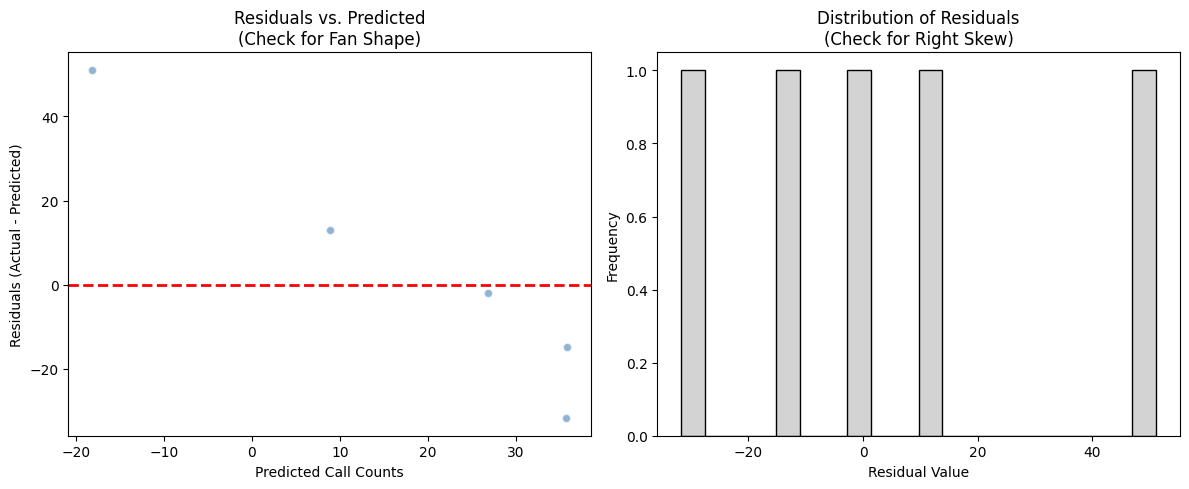

R-squared: -7.9239
Mean Absolute Error: 22.5316


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Prepare Features and Target
X = merged_df[['Ozone', 'PM2.5', 'Diesel PM', 'Drinking Water', 'Lead',
               'Pesticides', 'Tox. Release', 'Traffic', 'Cleanup Sites', 
               'Groundwater Threats', 'Haz. Waste', 'Solid Waste']]
y = merged_df['call_count']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# --- MATPLOTLIB DIAGNOSTIC PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Residuals vs Fitted (Test for Heteroskedasticity)
ax1.scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title("Residuals vs. Predicted\n(Check for Fan Shape)")
ax1.set_xlabel("Predicted Call Counts")
ax1.set_ylabel("Residuals (Actual - Predicted)")

# Plot 2: Histogram of Residuals (Check for Skew/Normality)
ax2.hist(residuals, bins=20, color='lightgray', edgecolor='black')
ax2.set_title("Distribution of Residuals\n(Check for Right Skew)")
ax2.set_xlabel("Residual Value")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")

## Divide by census tracts instead of zipcode

In [99]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

def assign_nearest_community(med_inc: pd.DataFrame,
                              communities: pd.DataFrame,
                              med_lat_col: str = 'latitude',
                              med_lon_col: str = 'longitude',
                              comm_lat_col: str = 'latitude',
                              comm_lon_col: str = 'longitude',
                              tract_col: str = 'Census_Tract') -> pd.DataFrame:
    """
    Assigns each medical incident to the nearest community region centroid
    using a vectorized cKDTree spatial join (fast, scales to millions of rows).

    Parameters
    ----------
    med_inc      : Medical incidents DataFrame (must have lat/lon columns)
    communities  : Community centroids DataFrame (must have lat/lon + Census_Tract)
    med_lat_col  : Name of latitude column in med_inc
    med_lon_col  : Name of longitude column in med_inc
    comm_lat_col : Name of latitude column in communities
    comm_lon_col : Name of longitude column in communities
    tract_col    : Name of the Census Tract identifier column in communities

    Returns
    -------
    med_inc copy with a new 'Census_Tract' column added.
    """

    def to_radians_array(lat, lon):
        """Convert lat/lon (degrees) to radians for Haversine-based KD-Tree."""
        return np.radians(np.column_stack([lat, lon]))

    # --- Drop rows with missing coordinates before building tree ---
    communities_clean = communities.dropna(subset=[comm_lat_col, comm_lon_col]).copy()
    med_inc_out = med_inc.copy()

    # Build KD-Tree on community centroids (in radians for arc-distance)
    comm_coords_rad = to_radians_array(
        communities_clean[comm_lat_col].values,
        communities_clean[comm_lon_col].values
    )
    tree = cKDTree(comm_coords_rad)

    # Query tree for each medical incident
    med_coords_rad = to_radians_array(
        med_inc_out[med_lat_col].values,
        med_inc_out[med_lon_col].values
    )

    # Handle NaN rows in med_inc gracefully
    valid_mask = ~(np.isnan(med_inc_out[med_lat_col].values) |
                   np.isnan(med_inc_out[med_lon_col].values))

    nearest_idx = np.full(len(med_inc_out), -1, dtype=int)
    _, nearest_idx[valid_mask] = tree.query(med_coords_rad[valid_mask], k=1)

    # Map index → Census_Tract value
    tract_values = communities_clean[tract_col].values
    med_inc_out['Census_Tract'] = np.where(
        nearest_idx >= 0,
        tract_values[nearest_idx],
        np.nan
    )

    # --- Diagnostics ---
    n_unmatched = (nearest_idx == -1).sum()
    if n_unmatched > 0:
        print(f"⚠️  {n_unmatched} rows had missing coordinates and were not assigned a tract.")
    print(f"✅  Assigned Census_Tract to {valid_mask.sum():,} of {len(med_inc_out):,} medical incidents.")
    print(f"    Unique tracts assigned: {med_inc_out['Census_Tract'].nunique()}")

    return med_inc_out

In [104]:
import re

def parse_point(point_str):
    """
    Parses a WKT POINT string like 'POINT (-122.411015164 37.78418755)'
    into (latitude, longitude) as floats.
    Returns (NaN, NaN) if parsing fails.
    """
    if pd.isna(point_str):
        return np.nan, np.nan
    match = re.search(r'POINT\s*\(\s*([-\d.]+)\s+([-\d.]+)\s*\)', str(point_str))
    if match:
        lon, lat = float(match.group(1)), float(match.group(2))
        return lat, lon
    return np.nan, np.nan


def extract_coords(med_inc: pd.DataFrame,
                   location_col: str = 'case_location') -> pd.DataFrame:
    """
    Adds '_latitude' and '_longitude' columns to med_inc parsed from
    the WKT POINT column. These are temporary working columns.
    """
    med_inc = med_inc.copy()
    coords = med_inc[location_col].apply(parse_point)
    med_inc['_latitude'] = coords.apply(lambda x: x[0])
    med_inc['_longitude'] = coords.apply(lambda x: x[1])
    return med_inc

In [109]:
# Step 1: extract coordinates from WKT POINT
med_inc = extract_coords(med_inc, location_col='case_location')

# Step 2: assign nearest Census_Tract
med_inc = assign_nearest_community(
    med_inc=med_inc,
    communities=hazards,
    med_lat_col='_latitude',
    med_lon_col='_longitude',
    comm_lat_col='Latitude',    # adjust to your actual column names
    comm_lon_col='Longitude',
    tract_col='Census Tract'
)

# Step 3: optionally drop the temp coordinate columns
med_inc = med_inc.drop(columns=['_latitude', '_longitude'])

✅  Assigned Census_Tract to 241,314 of 241,314 medical incidents.
    Unique tracts assigned: 198


In [111]:
med_inc

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location,geometry,Census_Tract
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755),POINT (-122.411015164 37.78418755),6.075013e+09
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006),POINT (-122.434729992 37.784944006),6.075016e+09
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351),POINT (-122.367922359 37.727398351),6.075981e+09
9,243660207,KM107,24182764,Medical Incident,12/31/2024,2024 Dec 31 03:14:07 AM,2024 Dec 31 03:14:07 AM,2024 Dec 31 03:15:12 AM,2024 Dec 31 03:16:18 AM,2024 Dec 31 03:20:49 AM,...,1,PRIVATE,1.0,2.0,5.0,Hayes Valley,243660207-KM107,POINT (-122.427913715 37.776253668),POINT (-122.427913715 37.776253668),6.075016e+09
10,243660194,M580,24182763,Medical Incident,12/31/2024,2024 Dec 31 02:58:32 AM,2024 Dec 31 02:58:32 AM,2024 Dec 31 02:59:16 AM,2024 Dec 31 02:59:24 AM,2024 Dec 31 03:15:04 AM,...,1,MEDIC,1.0,9.0,11.0,Excelsior,243660194-M580,POINT (-122.439640305 37.716958531),POINT (-122.439640305 37.716958531),6.075026e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368893,253643025,SCRT8,25186599,Medical Incident,12/30/2025,2025 Dec 30 08:48:09 PM,2025 Dec 30 08:48:09 PM,2025 Dec 30 08:48:23 PM,2025 Dec 30 08:48:27 PM,2025 Dec 30 09:06:45 PM,...,1,CP,1.0,5.0,8.0,Castro/Upper Market,253643025-SCRT8,POINT (-122.435187962 37.762670707),POINT (-122.435187962 37.762670707),6.075020e+09
368894,253642315,M504,25186491,Medical Incident,12/30/2025,2025 Dec 30 04:42:27 PM,2025 Dec 30 04:43:05 PM,2025 Dec 30 04:45:12 PM,2025 Dec 30 04:45:25 PM,NaN,...,1,MEDIC,2.0,2.0,6.0,South of Market,253642315-M504,POINT (-122.410401493 37.778785373),POINT (-122.410401493 37.778785373),6.075018e+09
368895,253640883,E08,25186295,Medical Incident,12/30/2025,2025 Dec 30 09:51:32 AM,2025 Dec 30 09:51:32 AM,2025 Dec 30 09:52:16 AM,2025 Dec 30 09:53:11 AM,2025 Dec 30 10:10:44 AM,...,1,ENGINE,2.0,3.0,6.0,South of Market,253640883-E08,POINT (-122.405847485 37.775231052),POINT (-122.405847485 37.775231052),6.075018e+09
368897,253641114,KM110,25186338,Medical Incident,12/30/2025,2025 Dec 30 11:08:11 AM,2025 Dec 30 11:10:08 AM,2025 Dec 30 11:13:18 AM,2025 Dec 30 11:14:16 AM,2025 Dec 30 11:21:23 AM,...,1,PRIVATE,2.0,3.0,3.0,Financial District/South Beach,253641114-KM110,POINT (-122.393263731 37.794229821),POINT (-122.393263731 37.794229821),6.075062e+09


In [122]:
import pandas as pd
from datetime import date

# Your existing code
med_inc['date_column'] = pd.to_datetime(med_inc['Call Date'], format='%m/%d/%Y')
d = date(2025, 1, 7)

# FIX: Convert d to a Timestamp
med_inc_week = med_inc[med_inc['date_column'] < pd.Timestamp(d)]

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_44074/17518399.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .centroid


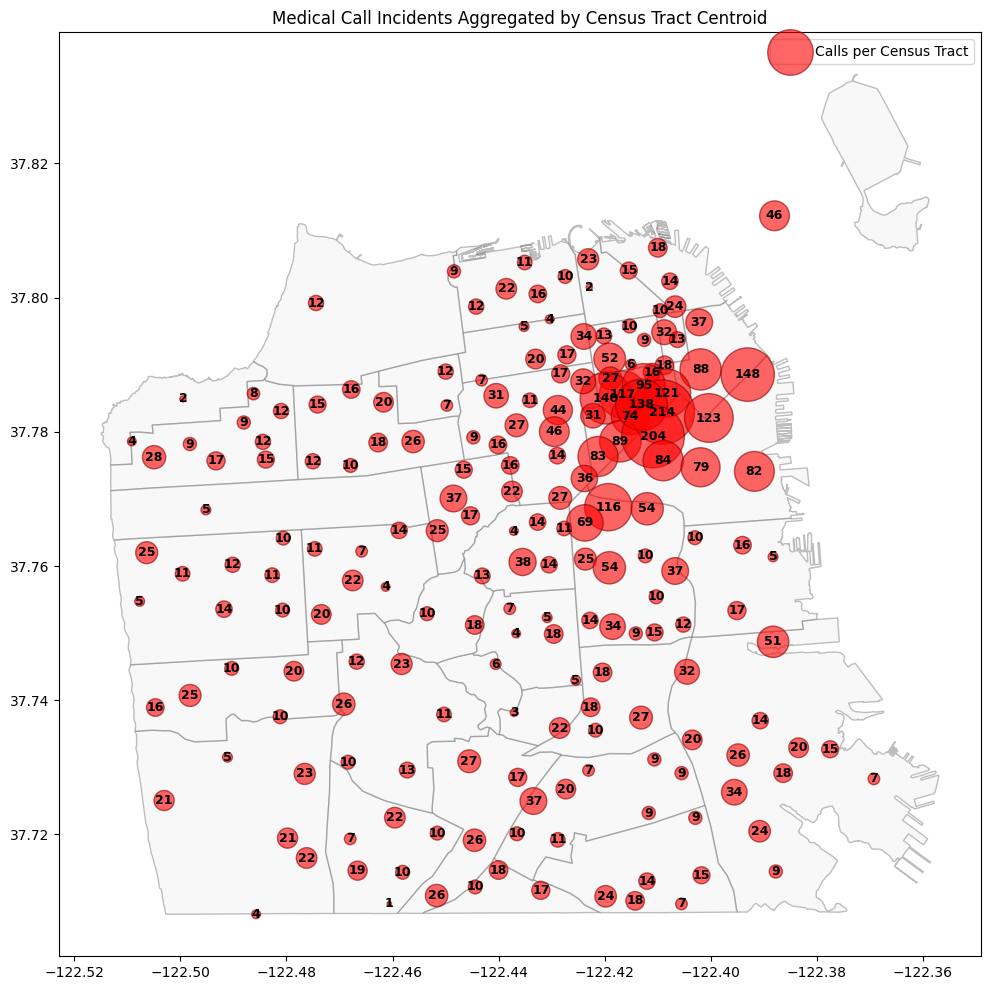

In [124]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

# 1. Load SF Map
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')
sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")

# 2. Prepare Medical Incidents
med_inc_week = med_inc_week.dropna(subset=['case_location'])
med_inc_week['geometry'] = med_inc_week['case_location'].apply(wkt.loads)
med_inc_gdf = gpd.GeoDataFrame(med_inc_week, geometry='geometry', crs="EPSG:4326")

# 3. Aggregate by Census_Tract
tract_counts = (
    med_inc_gdf
    .groupby('Census_Tract')
    .size()
    .reset_index(name='call_count')
)

# 4. Get Centroids per Census_Tract (centroid of all incident points in that tract)
tract_centroids = (
    med_inc_gdf
    .dissolve(by='Census_Tract')
    .centroid
)

tract_summary = gpd.GeoDataFrame(
    tract_counts,
    geometry=tract_centroids[tract_counts['Census_Tract']].values,
    crs="EPSG:4326"
)

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 12))

sf_map.plot(ax=ax, color='#f2f2f2', edgecolor='grey', alpha=0.5)

tract_summary.plot(
    ax=ax,
    color='red',
    markersize=tract_summary['call_count'] * 10,
    alpha=0.6,
    edgecolor='darkred',
    label='Calls per Census Tract'
)

for x, y, label in zip(tract_summary.geometry.x, tract_summary.geometry.y, tract_summary['call_count']):
    ax.text(x, y, str(label), fontsize=9, fontweight='bold', ha='center', va='center')

plt.title('Medical Call Incidents Aggregated by Census Tract Centroid')
plt.legend()
plt.show()

## Some suggestion work: 

In [1]:
# ============================================================
# 0. SETUP & DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from statsmodels.discrete.count_model import NegativeBinomial
import statsmodels.formula.api as smf
from scipy.spatial import cKDTree

# Load raw data
ems_calls = pd.read_csv("ems_calls.csv")        # lon, lat, timestamp
pollution = pd.read_csv("oehha_pollution.csv")   # census tract, pollutant cols, lon, lat

# ============================================================
# 1. DATA OVERVIEW — address reviewer comment on data size
# ============================================================

# Report total date range and number of weeks available
print("Date range:", ems_calls["timestamp"].min(), "to", ems_calls["timestamp"].max())
print("Total weeks:", ems_calls["week"].nunique())
print("Total census tracts:", pollution["census_tract"].nunique())  # should be 198
print("Total observations (tract x week):", ems_calls.groupby(["census_tract", "week"]).ngroups)

# ============================================================
# 2. SPATIAL ASSIGNMENT
# ============================================================

# Assign each EMS call to nearest census tract centroid using KD-tree
pollution_coords = pollution[["lon", "lat"]].values
tree = cKDTree(pollution_coords)
ems_coords = ems_calls[["lon", "lat"]].values
_, idx = tree.query(ems_coords)
ems_calls["census_tract"] = pollution.iloc[idx]["census_tract"].values

# Also assign zip code for robustness checks later
# ems_calls["zip_code"] = ...

# ============================================================
# 3. AGGREGATION — primary and alternative specifications
# ============================================================

# --- PRIMARY: census-tract x week ---
agg_tract_week = (
    ems_calls
    .groupby(["census_tract", "week", "year", "month"])
    .size()
    .reset_index(name="call_count")
)

# --- ALTERNATIVE 1: zip-code x week ---
agg_zip_week = (
    ems_calls
    .groupby(["zip_code", "week", "year", "month"])
    .size()
    .reset_index(name="call_count")
)

# --- ALTERNATIVE 2: census-tract x month ---
agg_tract_month = (
    ems_calls
    .groupby(["census_tract", "month", "year"])
    .size()
    .reset_index(name="call_count")
)

# Merge pollution covariates into each aggregation
covariates = ["ozone", "diesel", "drinking_water", "lead", "pesticides",
              "toxic_release", "traffic", "cleanup_sites", "groundwater",
              "hazardous_waste", "impaired_water", "solid_waste", "pollution_score"]

# Normalize covariates
pollution[covariates] = (pollution[covariates] - pollution[covariates].mean()) / pollution[covariates].std()

df_primary    = agg_tract_week.merge(pollution, on="census_tract")
df_alt_zip    = agg_zip_week.merge(pollution_by_zip, on="zip_code")    # aggregate pollution to zip
df_alt_month  = agg_tract_month.merge(pollution, on="census_tract")

# ============================================================
# 4. EDA — distributions, overdispersion, temporal trends
# ============================================================

# Check overdispersion
print("Mean call count:", df_primary["call_count"].mean())
print("Variance:", df_primary["call_count"].var())
print("Var/Mean ratio:", df_primary["call_count"].var() / df_primary["call_count"].mean())

# Weekly trend across all tracts
df_primary.groupby("week")["call_count"].mean().plot(title="Avg Weekly Call Volume Over Time")

# Seasonal pattern — does call volume vary by month?
df_primary.groupby("month")["call_count"].mean().plot(kind="bar", title="Avg Calls by Month")

# Spatial distribution — reproduce Figure 1 but across all time
# geopandas choropleth of mean call count per census tract

# ============================================================
# 5. PRIMARY MODEL — Negative Binomial (tract x week)
# ============================================================

# Base model: pollution covariates only
formula = "call_count ~ " + " + ".join(covariates)
model_base = smf.negativebinomial(formula, data=df_primary).fit()
print(model_base.summary())

# Add month fixed effects to capture seasonality
model_month_fe = smf.negativebinomial(
    formula + " + C(month)", data=df_primary
).fit()

# Add coarser geographic fixed effects (e.g. neighborhood or district)
# to capture spatial correlation between neighboring tracts
model_geo_fe = smf.negativebinomial(
    formula + " + C(month) + C(district)", data=df_primary
).fit()

# ============================================================
# 6. CLUSTERED STANDARD ERRORS
# ============================================================

# Cluster by census tract (accounts for within-tract correlation over time)
model_clustered_tract = model_base.get_robustcov_results(
    cov_type="cluster", groups=df_primary["census_tract"]
)

# Cluster by week (accounts for city-wide shocks in a given week)
model_clustered_week = model_base.get_robustcov_results(
    cov_type="cluster", groups=df_primary["week"]
)

print(model_clustered_tract.summary())
print(model_clustered_week.summary())

# ============================================================
# 7. ROBUSTNESS CHECKS — alternative aggregations
# ============================================================

# Fit same formula on zip x week
model_zip_week = smf.negativebinomial(formula, data=df_alt_zip).fit()

# Fit same formula on tract x month
model_tract_month = smf.negativebinomial(formula, data=df_alt_month).fit()

# Compare coefficients across models
coef_comparison = pd.DataFrame({
    "tract_week":   model_base.params,
    "zip_week":     model_zip_week.params,
    "tract_month":  model_tract_month.params,
}).loc[covariates]

coef_comparison.plot(kind="bar", title="Coefficient Comparison Across Aggregations")
plt.axhline(0, color="black", linewidth=0.8)

# Compare model fit (AIC/BIC)
print("AIC — tract x week:",  model_base.aic)
print("AIC — zip x week:",    model_zip_week.aic)
print("AIC — tract x month:", model_tract_month.aic)

# ============================================================
# 8. INFERENCE & INTERPRETATION
# ============================================================

# Which pollutants are significant after clustering SEs?
results_table = pd.DataFrame({
    "coef":    model_clustered_tract.params,
    "pval":    model_clustered_tract.pvalues,
    "ci_low":  model_clustered_tract.conf_int()[0],
    "ci_high": model_clustered_tract.conf_int()[1],
}).loc[covariates]

print(results_table.sort_values("pval"))

# Coefficient plot
plt.figure()
plt.errorbar(
    x=results_table["coef"],
    y=results_table.index,
    xerr=[results_table["coef"] - results_table["ci_low"],
          results_table["ci_high"] - results_table["coef"]],
    fmt="o"
)
plt.axvline(0, color="red", linestyle="--")
plt.title("Pollutant Coefficients with Clustered SEs (tract x week)")

ImportError: cannot import name 'NegativeBinomial' from 'statsmodels.discrete.count_model' (/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/discrete/count_model.py)